Importing Libraries and Dataset Load

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# CSV file read
data = pd.read_csv('recipes_muffins_cupcakes.csv')
data

,Type,Flour,Milk,Sugar,Butter,Egg,Baking Powder,Vanilla,Salt
0,Muffin,55,28,3,7,5,2,0,0
1,Muffin,47,24,12,6,9,1,0,0
2,Muffin,47,23,18,6,4,1,0,0
3,Muffin,45,11,17,17,8,1,0,0
4,Muffin,50,25,12,6,5,2,1,0
5,Muffin,55,27,3,7,5,2,1,0
6,Muffin,54,27,7,5,5,2,0,0
7,Muffin,47,26,10,10,4,1,0,0
8,Muffin,50,17,17,8,6,1,0,0
9,Muffin,50,17,17,11,4,1,0,0


Basic EDA

In [27]:
print("Shape:", data.shape)

print("\nInfo:")
print(data.info())

print("\nStatistics:")
print(data.describe())

print("\nClass Count:")
print(data['Type'].value_counts())

Shape: (20, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Type           20 non-null     object
 1   Flour          20 non-null     int64 
 2   Milk           20 non-null     int64 
 3   Sugar          20 non-null     int64 
 4   Butter         20 non-null     int64 
 5   Egg            20 non-null     int64 
 6   Baking Powder  20 non-null     int64 
 7   Vanilla        20 non-null     int64 
 8   Salt           20 non-null     int64 
dtypes: int64(8), object(1)
memory usage: 1.5+ KB
None

Statistics:
           Flour       Milk      Sugar     Butter        Egg  Baking Powder  \
count  20.000000  20.000000  20.000000  20.000000  20.000000      20.000000   
mean   43.900000  18.550000  17.100000  11.000000   7.200000       1.300000   
std     7.018022   6.801509   7.538672   4.801316   3.019237       0.732695   
min    34.000000   

Visulization

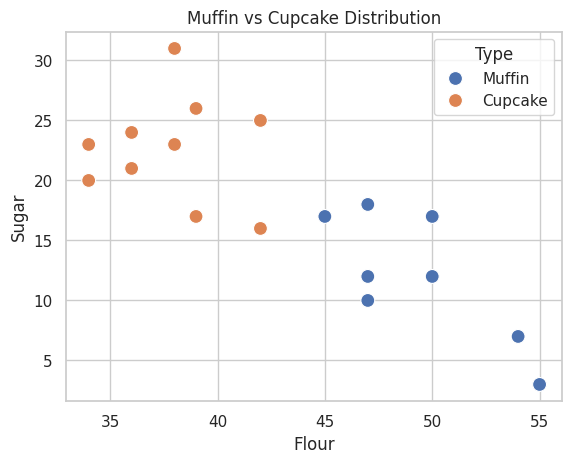

In [28]:
sns.scatterplot(x='Flour', y='Sugar', hue='Type', data=data, s=100)
plt.title("Muffin vs Cupcake Distribution")
plt.show()

Data Preparation

In [29]:
X = data[['Flour','Sugar']].values
y = np.where(data['Type']=='Muffin', 0, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SVM Model with Visualization

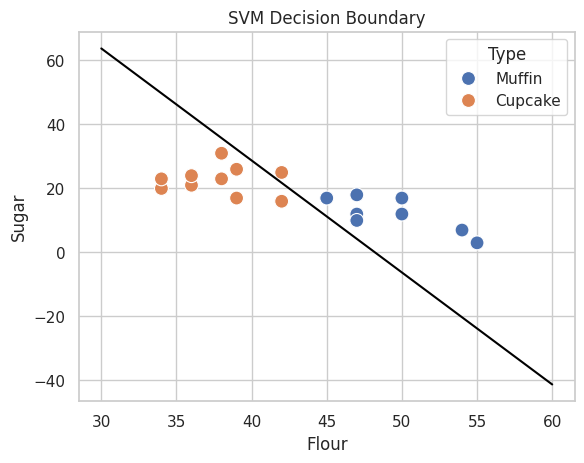

SVM Confusion Matrix:
[[2 0]
 [1 1]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [30]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Decision boundary
w = model.coef_[0]
slope = -w[0] / w[1]

x_line = np.linspace(30, 60)
y_line = slope * x_line - (model.intercept_[0] / w[1])

sns.scatterplot(x='Flour', y='Sugar', hue='Type', data=data, s=100)
plt.plot(x_line, y_line, color='black')

plt.title("SVM Decision Boundary")
plt.show()

# Evaluation
y_pred = model.predict(X_test)

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Model with Visualization

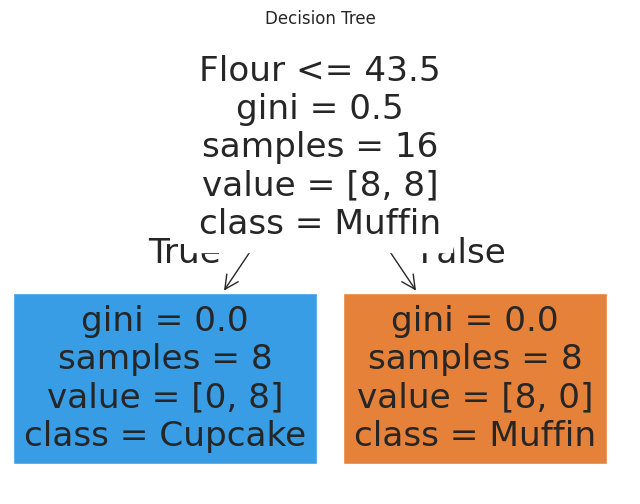

Decision Tree Confusion Matrix:
[[2 0]
 [0 2]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [31]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

from sklearn import tree

plt.figure(figsize=(8,6))
tree.plot_tree(dt_model, feature_names=['Flour','Sugar'],
               class_names=['Muffin','Cupcake'], filled=True)
plt.title("Decision Tree")
plt.show()

# Evaluation
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

KNN Model

In [32]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Evaluation
y_pred_knn = knn_model.predict(X_test)

print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Confusion Matrix:
[[2 0]
 [0 2]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Predictions

SVM: Muffin
DT: Muffin
KNN: Muffin


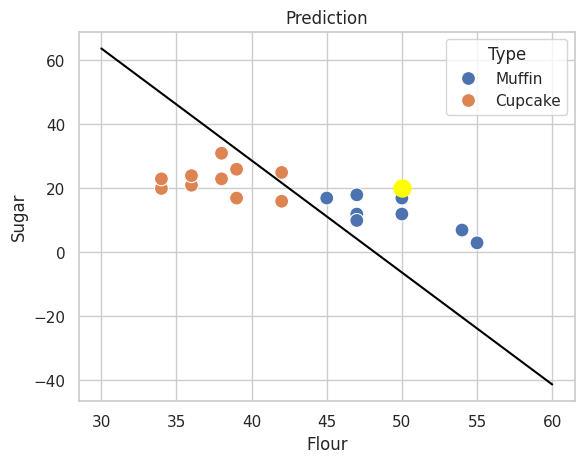

In [33]:
# new point
f, s = 50, 20

# predictions
p1 = model.predict([[f, s]])[0]
p2 = dt_model.predict([[f, s]])[0]
p3 = knn_model.predict([[f, s]])[0]

# print
print("SVM:", "Muffin" if p1==0 else "Cupcake")
print("DT:", "Muffin" if p2==0 else "Cupcake")
print("KNN:", "Muffin" if p3==0 else "Cupcake")

# plot
sns.scatterplot(x='Flour', y='Sugar', hue='Type', data=data, s=100)
plt.plot(x_line, y_line, color='black')

plt.scatter(f, s, color='yellow', s=150)

plt.title("Prediction")
plt.show()